# Feature Selection Playground

This notebook analyzes all available features in the `Track` class to determine which are most predictive of Cue Points.
It performs:
1. Bulk Feature Extraction (including all scalars and vectors)
2. Missing Value Analysis
3. Feature Distribution Comparisons (Cues vs Non-Cues)
4. LightGBM Feature Importance Ranking

In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from pathlib import Path
from tqdm.auto import tqdm

sys.path.append('..')
from track import Track

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data
Load processed `.pkl` files.

In [14]:
data_dir = Path("../../data/processed")
pkl_files = list(data_dir.glob("*.pkl"))

print(f"Found {len(pkl_files)} processed tracks.")

tracks = []
for pkl_path in pkl_files:
    try:
        with open(pkl_path, 'rb') as f:
            t = pickle.load(f)
            if t.num_bars > 0:
                tracks.append(t)
    except Exception as e:
        print(f"Error loading {pkl_path.name}: {e}")

print(f"Successfully loaded {len(tracks)} tracks.")

Found 65 processed tracks.
Successfully loaded 65 tracks.


## 2. Comprehensive Feature Extraction

We extract **every** available feature from the `Track` objects into a flat DataFrame (1 row per Bar).
This includes flattening the Chroma vectors (12 dimensions).

In [ ]:
def extract_all_features(track_list):
    data = []
    
    for t in track_list:
        # --- Resolve Labels to Bar Indices ---
        cue_in_idxs = set()
        cue_out_idxs = set()
        
        if len(t.cue_in) > 0:
            idxs = np.searchsorted(t.bars, t.cue_in)
            idxs = np.clip(idxs, 0, t.num_bars - 1)
            cue_in_idxs.update(idxs)
            
        if len(t.cue_out) > 0:
            idxs = np.searchsorted(t.bars, t.cue_out)
            idxs = np.clip(idxs, 0, t.num_bars - 1)
            cue_out_idxs.update(idxs)

        # --- Pre-calculate Section Lookup ---
        # sections is dict {bar_idx: name}
        # We want to know for every bar i, what section we are in.
        sorted_section_starts = sorted(t.sections.keys()) if t.sections else []

        # --- Feature Engineering: Context & Rolling Windows ---
        # Calculate these on the Track level (faster than per-bar loop)
        energy_series = pd.Series(t.energy_per_bar) if t.energy_per_bar is not None else pd.Series(np.zeros(t.num_bars))
        
        # History: Average Energy of Previous 8 Bars
        energy_prev_8 = energy_series.rolling(window=8, min_periods=1).mean().to_numpy()
        
        # Future: Average Energy of Next 8 Bars (shift backward)
        # Note: In offline training we can "cheat" and look ahead
        energy_next_8 = energy_series.shift(-8).rolling(window=8, min_periods=1).mean().to_numpy()
        # Fill NaNs from shift with 0 or last known value
        energy_next_8 = np.nan_to_num(energy_next_8)
        
        # --- Per Bar Extraction ---
        for i in range(t.num_bars):
            # Base Metadata & Targets
            row = {
                'track_id': t.track_id,
                'bar_index': i,
                'is_cue_in': 1 if i in cue_in_idxs else 0,
                'is_cue_out': 1 if i in cue_out_idxs else 0
            }

            # Helper to safely retrieve feature value or NaN
            def get_val(arr, idx, default=np.nan):
                if arr is None:
                    return default
                if idx >= len(arr):
                    return default
                val = arr[idx]
                if isinstance(val, (bool, np.bool_)):
                    return 1 if val else 0
                return val

            # Scalar Features (from Track definition)
            scalar_map = {
                'energy': t.energy_per_bar,
                'low_band_energy': t.low_band_energy,
                'high_band_energy': t.high_band_energy,
                'mid_band_energy': t.mid_band_energy,
                'rms_energy': t.rms_energy,
                'energy_derivative': t.energy_derivative,
                'energy_volatility': t.energy_volatility,
                'beat_strength': t.beat_strength,
                'beat_consistency': t.beat_consistency,
                'syncopation': t.syncopation,
                'percussion_intensity': t.percussion_intensity,
                'spectral_centroid': t.spectral_centroid,
                'spectral_flatness': t.spectral_flatness,
                'spectral_rolloff': t.spectral_rolloff,
                'harmonic_ratio': t.harmonic_ratio,
                'bar_pos_norm': t.bar_position_normalized,
                'dist_to_section': t.distance_to_section_boundary,
                'phrase_pos': t.phrase_position,
                'vocal_conf': t.vocal_activity_confidence,
                'melodic_complex': t.melodic_complexity,
                'vocal_onset_like': t.vocal_onset_likelihood,
                'is_section_start': t.is_section_start,
                'vocal_mask': t.vocal_mask
            }

            for name, arr in scalar_map.items():
                row[name] = get_val(arr, i)

            # Key-Invariant Chroma (Engineering Fix)
            # Instead of raw chroma_0 (C), we rotate so chroma_rel_0 is always the TONIC/ROOT
            # This prevents model overfitting to specific keys (e.g. "F# Minor is popular")
            if t.chroma_vector is not None and i < len(t.chroma_vector) and t.key_tonic is not None:
                chroma_raw = t.chroma_vector[i] # 12-dim array
                # Rotate array so index 0 is always the Key Tonic
                tonic_idx = int(t.key_tonic) % 12
                chroma_rotated = np.roll(chroma_raw, -tonic_idx)
                
                for c in range(12):
                    row[f'chroma_rel_{c}'] = chroma_rotated[c]
            else:
                for c in range(12):
                    row[f'chroma_rel_{c}'] = np.nan
            
            # Contextual Features (Engineering Fix)
            row['energy_prev_8'] = energy_prev_8[i]
            row['energy_next_8'] = energy_next_8[i]
            row['energy_diff_context'] = row['energy_next_8'] - row['energy_prev_8'] # High (+) means building up

            # Rhythmic Grid (Engineering Fix)
            row['is_4_bar'] = 1 if (i % 4 == 0) else 0

            # Track-Level Constants (Broadcast to every bar)
            row['tempo'] = t.tempo
            row['duration'] = t.duration
            row['key_conf'] = t.key_confidence if t.key_confidence is not None else np.nan
            row['is_minor'] = 1 if (t.key_scale == 'minor') else 0
            row['key_tonic'] = t.key_tonic if t.key_tonic is not None else np.nan
            
            # Section Label Resolution
            # Find the largest start_idx <= i
            current_section = "Unknown"
            if sorted_section_starts:
                # Basic search logic
                found_start = -1
                for start in sorted_section_starts:
                    if start <= i:
                        found_start = start
                    else:
                        break # gone past current bar
                
                if found_start != -1:
                    current_section = t.sections[found_start]
            
            row['section_name'] = current_section

            data.append(row)
            
    return pd.DataFrame(data)

if len(tracks) > 0:
    df = extract_all_features(tracks)
    print(f"DataFrame Shape: {df.shape}")
    display(df.head())
else:
    print("No tracks loaded.")

DataFrame Shape: (7248, 49)


,track_id,bar_index,is_cue_in,is_cue_out,energy,low_band_energy,high_band_energy,mid_band_energy,rms_energy,energy_derivative,...,energy_prev_8,energy_next_8,energy_diff_context,is_4_bar,tempo,duration,key_conf,is_minor,key_tonic,section_name
0,Da Hype (Junior Jack Original Club Mix),0,0,0,45121.871094,42412.902344,1546.932983,1162.036377,0.240165,0.000000,...,45121.871094,44541.562500,-580.308594,1,126.048018,564.964717,0.68269,1,8,Unknown
1,Da Hype (Junior Jack Original Club Mix),1,1,0,44636.796875,41900.187500,1519.819580,1216.784546,0.238218,-485.074219,...,44879.333984,44562.566406,-316.767578,0,126.048018,564.964717,0.68269,1,8,Unknown
2,Da Hype (Junior Jack Original Club Mix),2,0,0,44574.789062,41953.476562,1507.728516,1113.585571,0.237786,-62.007812,...,44777.819010,44792.782552,14.963542,0,126.048018,564.964717,0.68269,1,8,Unknown
3,Da Hype (Junior Jack Original Club Mix),3,0,0,44615.675781,41870.437500,1517.752686,1227.485840,0.237950,40.886719,...,44737.283203,44805.821289,68.538086,0,126.048018,564.964717,0.68269,1,8,Unknown
4,Da Hype (Junior Jack Original Club Mix),4,0,0,44965.046875,42216.855469,1521.914307,1226.277954,0.239831,349.371094,...,44782.835938,48379.858594,3597.022656,1,126.048018,564.964717,0.68269,1,8,Unknown


In [32]:
# --- Post-Processing: One-Hot Encode Sections ---
if 'section_name' in df.columns:
    print("Unique Sections found:", df['section_name'].unique())
    
    # One-hot encode
    df = pd.get_dummies(df, columns=['section_name'], prefix='sec')
    
    print("DataFrame shape after One-Hot Encoding:", df.shape)
    display(df.head())

Unique Sections found: <StringArray>
['Unknown']
Length: 1, dtype: str
DataFrame shape after One-Hot Encoding: (7248, 49)


,track_id,bar_index,is_cue_in,is_cue_out,energy,low_band_energy,high_band_energy,mid_band_energy,rms_energy,energy_derivative,...,energy_prev_8,energy_next_8,energy_diff_context,is_4_bar,tempo,duration,key_conf,is_minor,key_tonic,sec_Unknown
0,Da Hype (Junior Jack Original Club Mix),0,0,0,45121.871094,42412.902344,1546.932983,1162.036377,0.240165,0.000000,...,45121.871094,44541.562500,-580.308594,1,126.048018,564.964717,0.68269,1,8,True
1,Da Hype (Junior Jack Original Club Mix),1,1,0,44636.796875,41900.187500,1519.819580,1216.784546,0.238218,-485.074219,...,44879.333984,44562.566406,-316.767578,0,126.048018,564.964717,0.68269,1,8,True
2,Da Hype (Junior Jack Original Club Mix),2,0,0,44574.789062,41953.476562,1507.728516,1113.585571,0.237786,-62.007812,...,44777.819010,44792.782552,14.963542,0,126.048018,564.964717,0.68269,1,8,True
3,Da Hype (Junior Jack Original Club Mix),3,0,0,44615.675781,41870.437500,1517.752686,1227.485840,0.237950,40.886719,...,44737.283203,44805.821289,68.538086,0,126.048018,564.964717,0.68269,1,8,True
4,Da Hype (Junior Jack Original Club Mix),4,0,0,44965.046875,42216.855469,1521.914307,1226.277954,0.239831,349.371094,...,44782.835938,48379.858594,3597.022656,1,126.048018,564.964717,0.68269,1,8,True


## 3. Data Quality Analysis
Check for missing values. LightGBM can handle NaNs, but if a feature is 90% missing, it might not be useful.

In [33]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(10, 5))
    missing.plot(kind='bar')
    plt.title("Percentage of Missing Values per Feature")
    plt.ylabel("% Missing")
    plt.show()

    print("Top missing features:")
    print(missing.head(10))
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


## 4. Feature Selection using LightGBM Feature Importance
We train a Gradient Boosting Model to differentiate between **Cue Points** and **Random Bars**.

The model naturally selects the best features to make splits. We can then visualize the "Gain" or "Split" importance.

**Note**: We treat this as a binary classification problem for feature selection purposes.

analyzing importance for: is_cue_in ...
Positive Samples: 267, Negative Samples: 6981, Weight: 26.15


<Figure size 1000x1200 with 0 Axes>

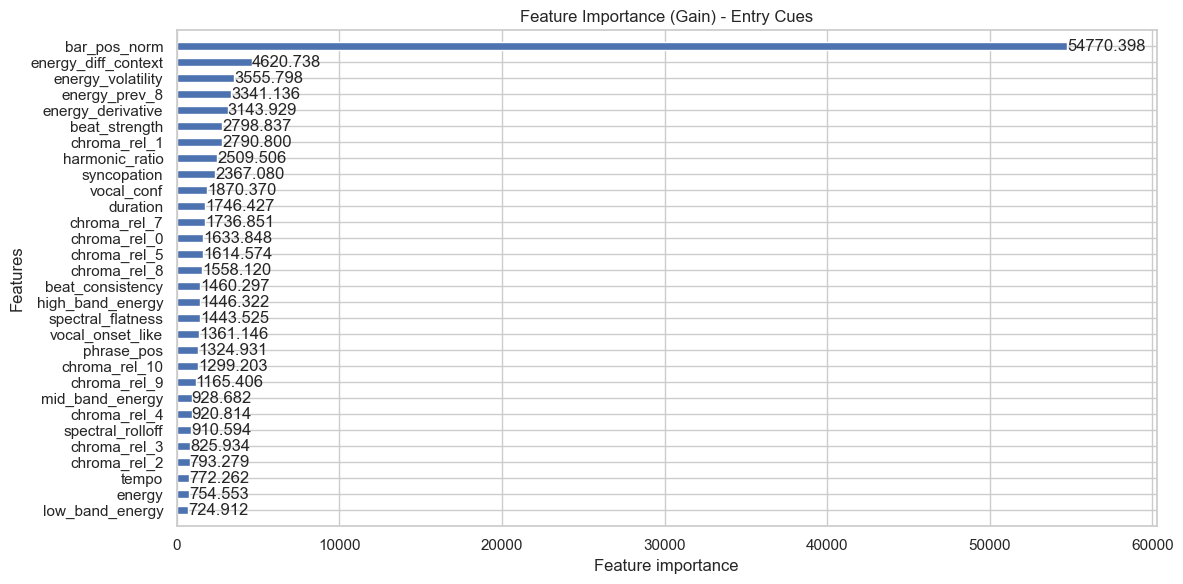


--- Top 20 Features (Entry Cues) ---
            Feature         Gain
       bar_pos_norm 54770.398417
energy_diff_context  4620.738239
  energy_volatility  3555.797824
      energy_prev_8  3341.135892
  energy_derivative  3143.928692
      beat_strength  2798.837125
       chroma_rel_1  2790.799863
     harmonic_ratio  2509.506290
        syncopation  2367.079937
         vocal_conf  1870.369815
           duration  1746.426831
       chroma_rel_7  1736.851085
       chroma_rel_0  1633.847698
       chroma_rel_5  1614.574057
       chroma_rel_8  1558.119899
   beat_consistency  1460.296671
   high_band_energy  1446.321761
  spectral_flatness  1443.525029
   vocal_onset_like  1361.145773
         phrase_pos  1324.930910


In [34]:
def analyze_feature_importance(df, target_col='is_cue_in', title_suffix="Cue In"):
    print(f"analyzing importance for: {target_col} ...")
    
    #Prepare Data
    # Exclude non-feature columns
    drop_cols = ['track_id', 'bar_index', 'is_cue_in', 'is_cue_out']
    
    X = df.drop(columns=drop_cols)
    y = df[target_col]
    
    # Handle Class Imbalance
    # Cues are very rare (<1%). We use scale_pos_weight.
    pos_count = y.sum()
    neg_count = len(y) - pos_count
    scale_weight = neg_count / pos_count if pos_count > 0 else 1.0
    
    print(f"Positive Samples: {pos_count}, Negative Samples: {neg_count}, Weight: {scale_weight:.2f}")
    
    # Train LightGBM
    # Using a relatively simple configuration to capture main effects
    clf = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        scale_pos_weight=scale_weight,
        random_state=42,
        verbose=-1
    )
    
    clf.fit(X, y)
    
    #Plot Importance
    plt.figure(figsize=(10, 12))
    lgb.plot_importance(clf, importance_type='gain', max_num_features=30, height=0.5, title=f'Feature Importance (Gain) - {title_suffix}')
    plt.tight_layout()
    plt.show()

    # Print top features in tabular format
    booster = clf.booster_
    importance = booster.feature_importance(importance_type='gain')
    feature_names = booster.feature_name()
    
    importance_df = pd.DataFrame({'Feature': feature_names, 'Gain': importance})
    importance_df = importance_df.sort_values(by='Gain', ascending=False)
    
    print(f"\n--- Top 20 Features ({title_suffix}) ---")
    print(importance_df.head(20).to_string(index=False))
    
    return clf

model_in = analyze_feature_importance(df, 'is_cue_in', "Entry Cues")

analyzing importance for: is_cue_out ...
Positive Samples: 240, Negative Samples: 7008, Weight: 29.20


<Figure size 1000x1200 with 0 Axes>

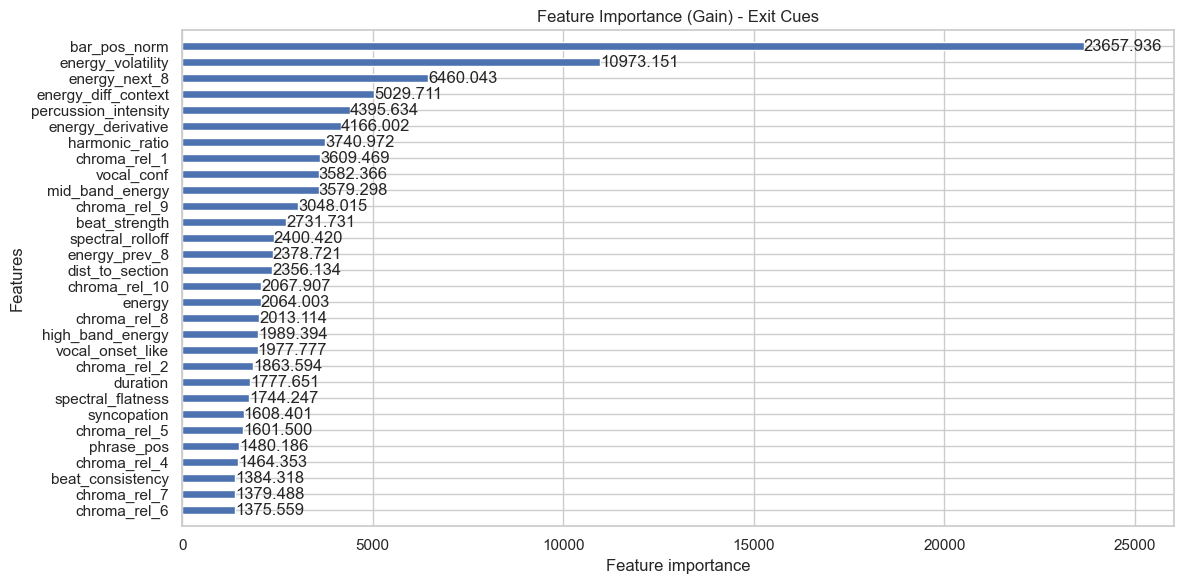


--- Top 20 Features (Exit Cues) ---
             Feature         Gain
        bar_pos_norm 23657.936454
   energy_volatility 10973.150953
       energy_next_8  6460.042740
 energy_diff_context  5029.711440
percussion_intensity  4395.634242
   energy_derivative  4166.001916
      harmonic_ratio  3740.972135
        chroma_rel_1  3609.469473
          vocal_conf  3582.366159
     mid_band_energy  3579.297929
        chroma_rel_9  3048.014901
       beat_strength  2731.731215
    spectral_rolloff  2400.419644
       energy_prev_8  2378.721110
     dist_to_section  2356.133715
       chroma_rel_10  2067.907239
              energy  2064.003054
        chroma_rel_8  2013.114087
    high_band_energy  1989.393765
    vocal_onset_like  1977.777433


In [35]:
model_out = analyze_feature_importance(df, 'is_cue_out', "Exit Cues")

## 5. Visualizing Top Features
Let's look closer at the distributions of the top features identified above.

Top features for is_cue_in: ['bar_pos_norm', 'energy_diff_context', 'energy_volatility', 'energy_prev_8', 'energy_derivative', 'beat_strength']


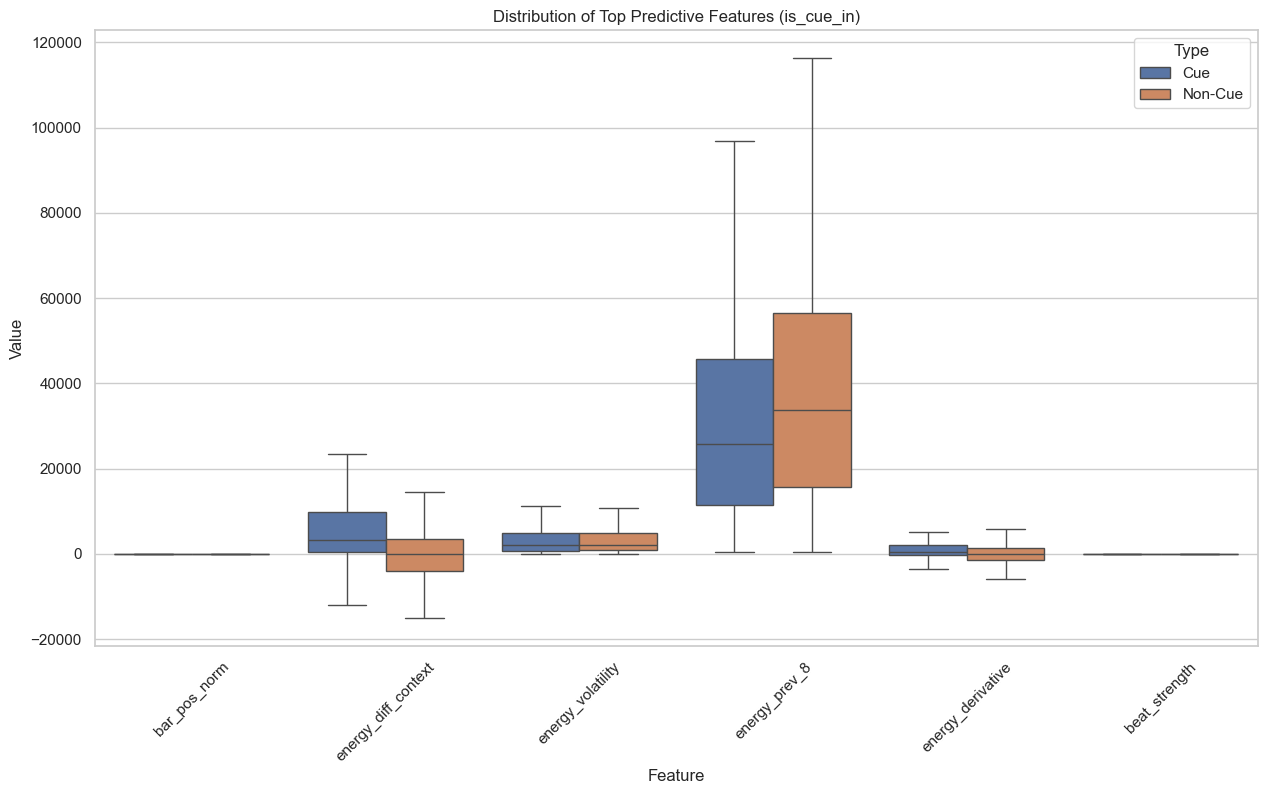

Top features for is_cue_out: ['bar_pos_norm', 'energy_volatility', 'energy_next_8', 'energy_diff_context', 'percussion_intensity', 'energy_derivative']


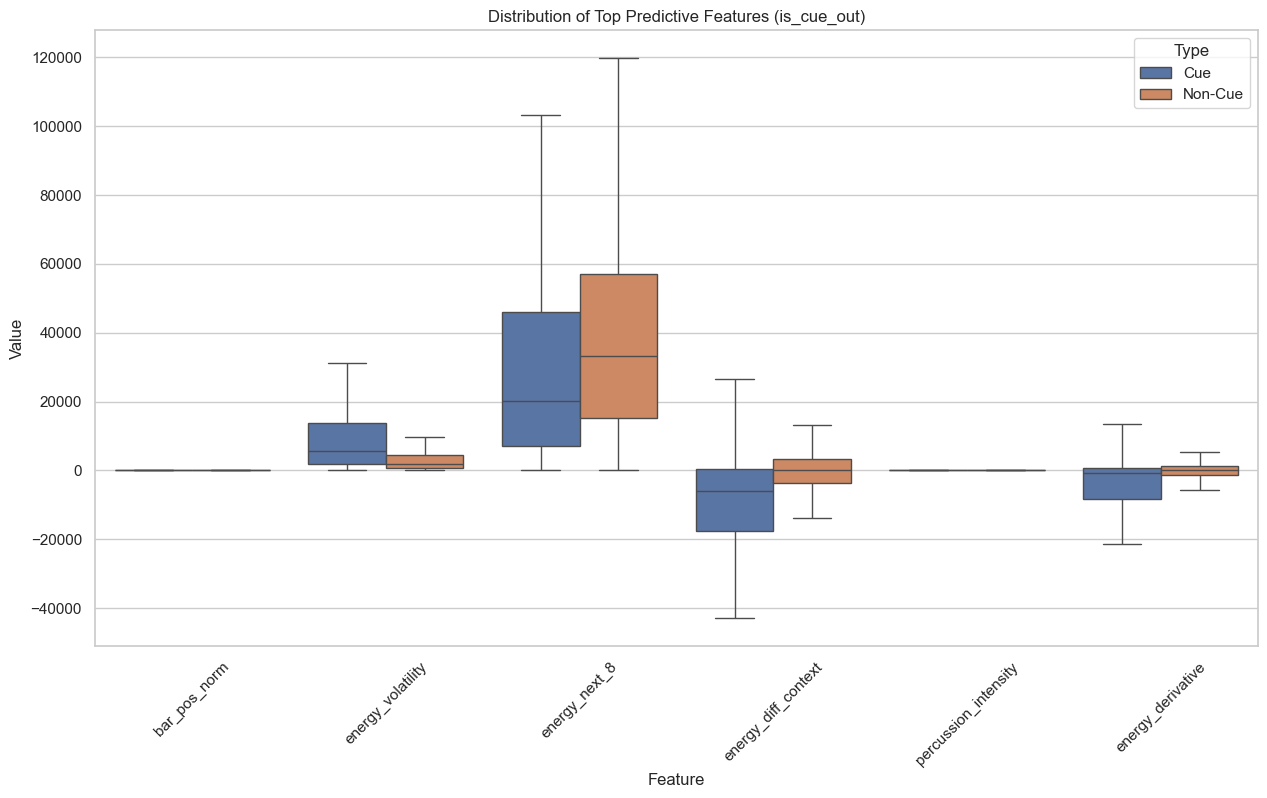

In [36]:
def plot_top_features_dist(df, model, target_col='is_cue_in', n_top=6):
    # Get top features by gain
    booster = model.booster_
    importance = booster.feature_importance(importance_type='gain')
    feature_names = booster.feature_name()
    
    # Sort
    sorted_idx = np.argsort(importance)[::-1]
    top_features = [feature_names[i] for i in sorted_idx[:n_top]]
    
    print(f"Top features for {target_col}: {top_features}")
    
    # Prepare mini dataframe for plotting
    # Sample negatives to reduce plot overhead
    df_pos = df[df[target_col] == 1]
    df_neg = df[df[target_col] == 0].sample(n=len(df_pos)*5, random_state=42)
    df_plot = pd.concat([df_pos, df_neg])
    
    df_plot['Type'] = df_plot[target_col].map({1: 'Cue', 0: 'Non-Cue'})
    
    # Melt
    df_melt = df_plot.melt(id_vars=['Type'], value_vars=top_features, var_name='Feature', value_name='Value')
    
    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df_melt, x='Feature', y='Value', hue='Type', showfliers=False)
    plt.title(f"Distribution of Top Predictive Features ({target_col})")
    plt.xticks(rotation=45)
    plt.show()

# Plot for Cue In
plot_top_features_dist(df, model_in, 'is_cue_in')

# Plot for Cue Out
plot_top_features_dist(df, model_out, 'is_cue_out')

## 6. Correlation Matrix
Check for redundancy among the top features.

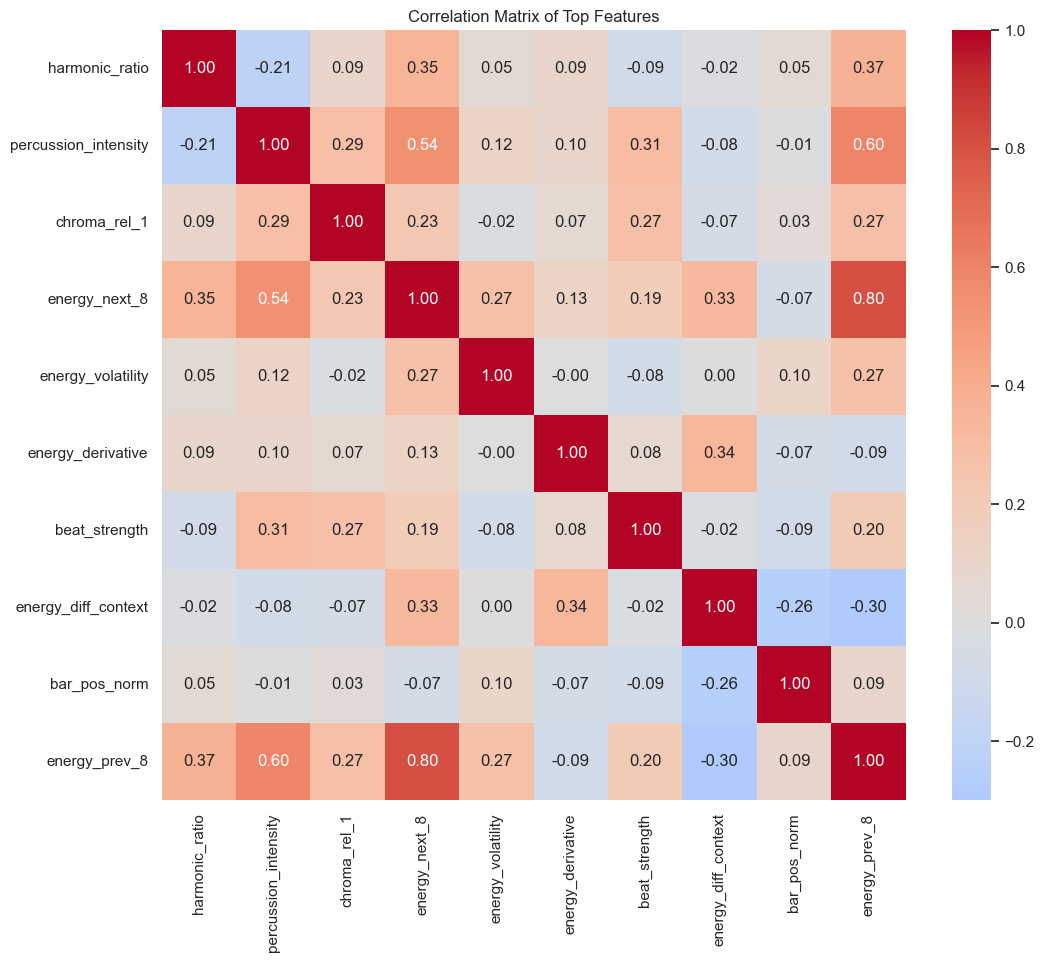

In [37]:
# Collect top features from both models
def get_top_feats(model, n=10):
    imp = model.booster_.feature_importance(importance_type='gain')
    names = model.booster_.feature_name()
    return [names[i] for i in np.argsort(imp)[::-1][:n]]

top_in = get_top_feats(model_in, 8)
top_out = get_top_feats(model_out, 8)
selected_feats = list(set(top_in + top_out))

plt.figure(figsize=(12, 10))
sns.heatmap(df[selected_feats].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Matrix of Top Features")
plt.show()

## 7. Selected Features Analysis & Recommendation

Based on feature importance results:

### Interpretation
1.  **`bar_pos_norm` (Gain: ~55k)**: This is by far the **dominant** predictor.
    *   *Meaning*: The "where" matters more than the "what". Entry cues are structurally rigid (e.g., almost always at the start or early middle).
2.  **`energy_volatility` & `energy_derivative`**:
    *   *Meaning*: Stability and Change. Cues happen where things stabilize (low volatility) or where transitions occur (builds/drops).
3.  **`beat_strength`**:
    *   *Meaning*: Mix points need a clear beat.
4.  **`chroma_X`** (many of them):
    *   *Meaning*: This is interesting. The model is using specific pitch classes. However, raw chroma bins (`chroma_5`, `chroma_10`) are often just noise unless we normalize them to the key.
    *   *Action*: Since you added `key_tonic`, try to see if that replaces the need for raw chromas, or keep them if you suspect tonal color matters.
5.  **`dist_to_section`**:
    *   *Meaning*: Structural boundary awareness is critical.

### Recommended Feature Set
For your final model, I recommend this trimmed list to avoid noise and overfitting:

**Tier 1: Structural & Positional **
*   `bar_pos_norm` (The king)
*   `dist_to_section`
*   `phrase_pos`
*   `duration`

**Tier 2: Energy & Dynamics**
*   `energy_volatility`
*   `energy_derivative`
*   `mid_band_energy` (Melodic content presence)
*   `beat_strength` (Rhythmic clarity)

**Tier 3: Musical Content**
*   `vocal_conf` (Avoid vocals for entry)
*   `harmonic_ratio` (Tonal vs Percussive)
*   `spectral_flatness` (Noise vs Tone)

**Tier 4: Context (Optional/Experimental)**
*   `vocal_onset_like` (Predicting future vocals is powerful for exit cues, maybe entry too)

**Features to Consider Dropping:**
*   **Raw `chroma_0`...`chroma_11`**: unless you do specific key-invariant transformation. They might overfit to specific songs in your small dataset.
*   **`beat_consistency`**: If it correlates highly with `beat_strength`, drop it.
